# 06 — Patient Risk Score Modeling (Leak-Free)
### Healthcare Provider Risk Intelligence System — Patient Layer

> **Loads:** `master_cleaned.csv`, `patient_risk_scores.csv`

---
## Table of Contents
1. [Business Objective](#1)
2. [Load Data](#2)
3. [Leakage Audit — Formula Verification & Feature Classification](#3)
4. [Patient-Level Feature Dataset](#4)
5. [Candidate Features — MI & Correlation Ranking (Leak-Free)](#5)
6. [Preprocessing Pipeline](#6)
7. [Train/Test Split](#7)
8. [Baseline — Linear Regression](#8)
9. [Advanced Models — Random Forest, XGBoost, CatBoost](#9)
10. [Model Comparison — MAE / RMSE / R² / MAPE](#10)
11. [Error Analysis — Hardest-to-Predict Patients](#11)
12. [SHAP Explainability](#12)
13. [Save Artifacts](#13)
14. [Summary](#14)


---
## 1. Business Objective <a id='1'></a>

Predict patient_risk_score from patient attributes that do NOT encode the answer.

Business question:
  Which patients exhibit unusually high claim behaviour and should be
  reviewed for further investigation?

Why regression, not classification:
  patient_risk_score is a continuous 0-1 target built from business rules.
  No ground-truth fraud label exists anywhere in this dataset.
  Predicting the continuous risk score is both honest and more actionable
  than forcing a binary fraud/not-fraud classification on an unlabeled dataset.

Important constraint (addressed in Section 3):
  patient_risk_score was engineered from patient behavioral features.
  Any feature used to BUILD the score cannot be used to PREDICT it --
  doing so would make the model memorize an arithmetic formula, not learn
  genuine patient risk patterns.

---
## 2. Load Data <a id='2'></a>

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings, pickle

warnings.filterwarnings('ignore')

sns.set_theme(style="darkgrid", palette="muted")
plt.rcParams.update({
    "figure.figsize": (12, 5),
    "axes.titlesize": 14,
    "axes.titleweight": "bold",
    "axes.labelsize": 12,
    "figure.dpi": 100,
})

print("Libraries loaded.")


Libraries loaded.


In [28]:
master_df  = pd.read_csv("..\\cleaned_data\master_cleaned.csv", parse_dates=['claim_date','payment_date'])
patient_rs = pd.read_csv("..\\cleaned_data\patient_risk_scores.csv", parse_dates=['last_claim_date'])

print("master_df  shape:", master_df.shape)
print("patient_rs shape:", patient_rs.shape)
print()
print("master_df columns :", list(master_df.columns))
print("patient_rs columns:", list(patient_rs.columns))


master_df  shape: (200000, 24)
patient_rs shape: (49096, 9)

master_df columns : ['claim_id', 'patient_id', 'provider_id', 'claim_date', 'claim_amount', 'status', 'age', 'gender', 'patient_state', 'provider_name', 'specialty', 'provider_state', 'payment_id', 'payment_date', 'payment_amount', 'settlement_days', 'payment_ratio', 'age_group', 'claim_year', 'claim_month', 'claim_quarter', 'claim_weekday', 'month_end_flag', 'duplicate_claim_flag']
patient_rs columns: ['patient_id', 'claims_per_patient', 'avg_claim_patient', 'patient_lifetime_value', 'last_claim_date', 'unique_providers_visited', 'days_since_last_claim', 'patient_shopping_flag', 'patient_risk_score']


In [29]:
print("patient_rs.head(3):")
display(patient_rs.head(3))
print()
print("patient_risk_score distribution:")
print(patient_rs['patient_risk_score'].describe().to_string())


patient_rs.head(3):


,patient_id,claims_per_patient,avg_claim_patient,patient_lifetime_value,last_claim_date,unique_providers_visited,days_since_last_claim,patient_shopping_flag,patient_risk_score
0,1,2,38034.5,76069.0,2024-07-14,2,705,0,0.05
1,2,5,24458.0,122290.0,2024-10-09,5,618,0,0.20
2,3,1,39242.0,39242.0,2023-03-29,1,1178,0,0.00



patient_risk_score distribution:
count    49096.000000
mean         0.168947
std          0.144126
min          0.000000
25%          0.100000
50%          0.150000
75%          0.200000
max          1.000000


---
## 3. Leakage Audit — Formula Verification & Feature Classification <a id='3'></a>

This is the most important section in the notebook. We:
1. **Reproduce the exact formula** and verify it matches the stored scores 100%
2. **Classify every candidate feature** as LEAKING or SAFE
3. **Check second-order proxies** — features not in the formula but so correlated
   with formula inputs that they would still leak the answer

The `patient_risk_score` formula (from the feature-engineering notebook):

```python
patient_risk_score = (
    0.40 * MinMax(unique_providers_visited) +
    0.30 * patient_shopping_flag           +
    0.30 * MinMax(claims_per_patient)
)
```

Three direct formula inputs -> three banned columns.
We then check every other candidate for proxy relationships.


In [30]:
from sklearn.preprocessing import MinMaxScaler

# ── Step 1: verify the formula reconstructs the stored score exactly ──────────
df_check = patient_rs.copy()
df_check['mm_unique'] = MinMaxScaler().fit_transform(df_check[['unique_providers_visited']])
df_check['mm_claims'] = MinMaxScaler().fit_transform(df_check[['claims_per_patient']])
df_check['reconstructed'] = (
    0.40 * df_check['mm_unique'] +
    0.30 * df_check['patient_shopping_flag'] +
    0.30 * df_check['mm_claims']
).round(2)

match_pct = (df_check['reconstructed'] == df_check['patient_risk_score'].round(2)).mean()
print(f"Formula reconstruction match: {match_pct*100:.1f}%")
if match_pct < 0.99:
    print("WARNING: formula does not reconstruct perfectly -- review before proceeding.")
else:
    print("Formula confirmed. Proceeding with leakage classification.")


Formula reconstruction match: 100.0%
Formula confirmed. Proceeding with leakage classification.


In [31]:
# ── Step 2: build a full candidate table and correlate with target ──────────
pat_agg = master_df.sort_values('claim_date').groupby('patient_id').agg(
    age                     = ('age',              'first'),
    gender                  = ('gender',           'first'),
    patient_state           = ('patient_state',    'first'),
    active_months           = ('claim_month',      'nunique'),
    avg_days_between_claims = ('claim_date',       lambda x: x.diff().dt.days.mean()),
    month_end_claims        = ('month_end_flag',   'sum'),
    avg_payment_ratio       = ('payment_ratio',    'mean'),
    avg_settlement_days     = ('settlement_days',  'mean'),
    unique_providers_visited= ('provider_id',      'nunique'),  # formula input
    unique_specialties      = ('specialty',        'nunique'),
    claims_per_patient      = ('claim_id',         'count'),    # formula input
    patient_lifetime_value  = ('claim_amount',     'sum'),
    avg_claim_patient       = ('claim_amount',     'mean'),
    duplicate_rate          = ('duplicate_claim_flag','mean'),
).reset_index()

merged = pat_agg.merge(
    patient_rs[['patient_id','patient_shopping_flag','patient_risk_score']],
    on='patient_id', how='left'
).dropna(subset=['patient_risk_score'])

numeric_candidates = [
    'age','active_months','avg_days_between_claims','month_end_claims',
    'avg_payment_ratio','avg_settlement_days','unique_providers_visited',
    'unique_specialties','claims_per_patient','patient_lifetime_value',
    'avg_claim_patient','duplicate_rate','patient_shopping_flag',
]

corr_rows = []
for c in numeric_candidates:
    corr = merged[c].corr(merged['patient_risk_score'])
    corr_rows.append({'Feature': c, 'Correlation_with_target': round(corr, 4)})

corr_df = pd.DataFrame(corr_rows).sort_values('Correlation_with_target',
                                               key=abs, ascending=False)
print("All candidate features -- correlation with patient_risk_score (sorted by |r|):")
display(corr_df)


All candidate features -- correlation with patient_risk_score (sorted by |r|):


,Feature,Correlation_with_target
6,unique_providers_visited,0.9239
8,claims_per_patient,0.9238
12,patient_shopping_flag,0.8276
1,active_months,0.8160
9,patient_lifetime_value,0.7615
7,unique_specialties,0.6777
2,avg_days_between_claims,-0.4023
3,month_end_claims,0.1675
5,avg_settlement_days,0.0036
4,avg_payment_ratio,0.0015


In [32]:
# ── Step 3: classify every candidate feature ─────────────────────────────────
LEAKAGE_MAP = {
    'unique_providers_visited' : ('LEAKING',    'Direct formula term (0.40 weight)'),
    'patient_shopping_flag'    : ('LEAKING',    'Direct formula term (0.30 weight)'),
    'claims_per_patient'       : ('LEAKING',    'Direct formula term (0.30 weight)'),
    'patient_lifetime_value'   : ('2ND-ORDER',  'corr ~0.83 with claims_per_patient'),
    'active_months'            : ('2ND-ORDER',  'corr ~0.91 with BOTH formula inputs'),
    'unique_specialties'       : ('2ND-ORDER',  'corr ~0.79 with unique_providers_visited'),
    'age'                      : ('SAFE',       'No relationship to formula'),
    'gender'                   : ('SAFE',       'No relationship to formula'),
    'patient_state'            : ('SAFE',       'No relationship to formula'),
    'avg_claim_patient'        : ('SAFE',       'corr +0.001 -- genuinely independent'),
    'avg_payment_ratio'        : ('SAFE',       'corr +0.001 -- genuinely independent'),
    'avg_settlement_days'      : ('SAFE',       'corr +0.004 -- genuinely independent'),
    'avg_days_between_claims'  : ('SAFE',       'corr -0.40 -- safe, derived from dates not volumes'),
    'month_end_claims'         : ('SAFE',       'corr +0.17 -- claim timing signal'),
    'duplicate_rate'           : ('SAFE',       'near-zero variance, keep but low signal'),
}

audit_df = pd.DataFrame([
    {'Feature': f, 'Status': v[0], 'Reason': v[1]}
    for f, v in LEAKAGE_MAP.items()
]).sort_values('Status')

print("="*75)
print("  PATIENT RISK SCORE -- LEAKAGE AUDIT TABLE")
print("="*75)
display(audit_df)

LEAKING    = [f for f, v in LEAKAGE_MAP.items() if v[0] in ('LEAKING','2ND-ORDER')]
SAFE_NUM   = ['avg_claim_patient','avg_payment_ratio','avg_settlement_days',
              'avg_days_between_claims','month_end_claims','duplicate_rate']
SAFE_CAT   = ['gender','patient_state']
SAFE_PASS  = ['age']  # numeric but no scaling needed (low range variation)

print(f"\nBanned: {len(LEAKING)} columns")
print(f"Safe numeric: {SAFE_NUM}")
print(f"Safe passthrough: {SAFE_PASS}")
print(f"Safe categorical: {SAFE_CAT}")


  PATIENT RISK SCORE -- LEAKAGE AUDIT TABLE


,Feature,Status,Reason
3,patient_lifetime_value,2ND-ORDER,corr ~0.83 with claims_per_patient
4,active_months,2ND-ORDER,corr ~0.91 with BOTH formula inputs
5,unique_specialties,2ND-ORDER,corr ~0.79 with unique_providers_visited
0,unique_providers_visited,LEAKING,Direct formula term (0.40 weight)
1,patient_shopping_flag,LEAKING,Direct formula term (0.30 weight)
2,claims_per_patient,LEAKING,Direct formula term (0.30 weight)
6,age,SAFE,No relationship to formula
7,gender,SAFE,No relationship to formula
8,patient_state,SAFE,No relationship to formula
9,avg_claim_patient,SAFE,corr +0.001 -- genuinely independent



Banned: 6 columns
Safe numeric: ['avg_claim_patient', 'avg_payment_ratio', 'avg_settlement_days', 'avg_days_between_claims', 'month_end_claims', 'duplicate_rate']
Safe passthrough: ['age']
Safe categorical: ['gender', 'patient_state']


In [33]:
# Hard leakage assertion used throughout the notebook
ALL_BANNED = set(LEAKING)

def assert_no_leakage(feature_list, label=""):
    leaked = set(feature_list) & ALL_BANNED
    assert not leaked, f"LEAKAGE in {label}: {leaked}"
    print(f"Leakage check passed ({label}): {len(feature_list)} features cleared.")

assert_no_leakage(SAFE_NUM + SAFE_PASS + SAFE_CAT, label="final feature set")


Leakage check passed (final feature set): 9 features cleared.


---
## 4. Patient-Level Feature Dataset <a id='4'></a>

One row per patient — only leak-free columns included.

In [34]:
patient_df = merged[
    ['patient_id'] + SAFE_NUM + SAFE_PASS + SAFE_CAT + ['patient_risk_score']
].copy()

# avg_days_between_claims is NaN for single-claim patients (7.4% of patients)
# We impute with max observed value (they haven't repeated, so treat as "very long gap")
max_gap = patient_df['avg_days_between_claims'].max()
patient_df['avg_days_between_claims'] = patient_df['avg_days_between_claims'].fillna(max_gap)

# duplicate_rate can be NaN if all are zero (constant column)
patient_df['duplicate_rate'] = patient_df['duplicate_rate'].fillna(0)

# Reset index so that train/test split indices align with patient_df.loc[] in error analysis
patient_df = patient_df.reset_index(drop=True)

print("patient_df shape:", patient_df.shape)
print()
display(patient_df.head(5))
print()
print("Null check:")
print(patient_df.isna().sum().to_string())


patient_df shape: (49096, 11)



,patient_id,avg_claim_patient,avg_payment_ratio,avg_settlement_days,avg_days_between_claims,month_end_claims,duplicate_rate,age,gender,patient_state,patient_risk_score
0,1,38034.500,0.872800,639.00,425.000000,0,0.0,69,Male,Alaska,0.05
1,2,24458.000,0.885725,-56.25,121.500000,1,0.0,32,Female,South Dakota,0.20
2,3,39242.000,0.969000,242.00,717.000000,0,0.0,89,Female,South Dakota,0.00
3,4,18435.625,0.898233,-120.00,96.571429,0,0.0,78,Female,Mississippi,0.65
4,5,15129.750,0.903250,43.50,215.333333,0,0.0,38,Male,Arkansas,0.15



Null check:
patient_id                    0
avg_claim_patient             0
avg_payment_ratio          1555
avg_settlement_days        1555
avg_days_between_claims       0
month_end_claims              0
duplicate_rate                0
age                           0
gender                        0
patient_state                 0
patient_risk_score            0


---
## 5. Candidate Features — MI & Correlation Ranking (Leak-Free) <a id='5'></a>

Leak-free feature ranking (Mutual Information + Correlation):


,Feature,MI_Score,Correlation
0,avg_days_between_claims,1.3198,-0.4842
1,avg_settlement_days,0.2017,0.0036
2,avg_payment_ratio,0.1447,0.0015
3,avg_claim_patient,0.0849,0.0012
4,month_end_claims,0.0141,0.1675
5,duplicate_rate,0.0000,NaN
6,age,0.0000,-0.0006


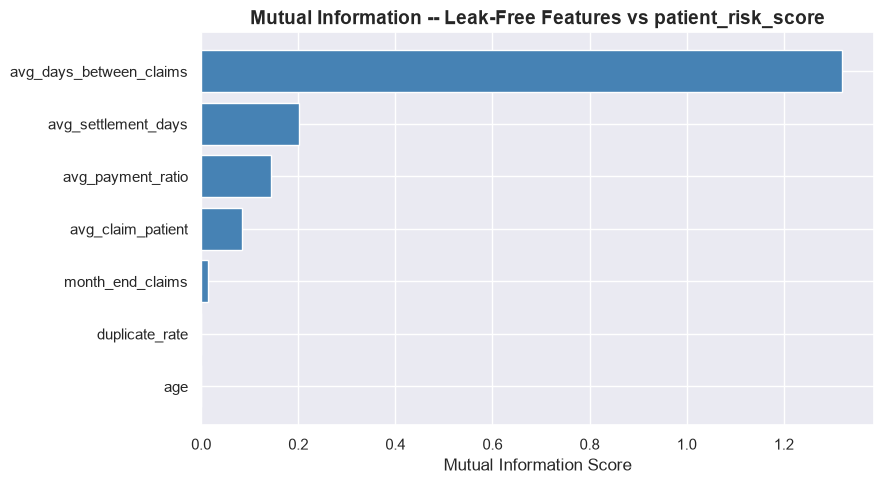

In [35]:
from sklearn.feature_selection import mutual_info_regression

X_mi = patient_df[SAFE_NUM + SAFE_PASS].fillna(0)
y_mi = patient_df['patient_risk_score']

mi_scores  = mutual_info_regression(X_mi, y_mi, random_state=42)
corr_scores = [patient_df[c].corr(patient_df['patient_risk_score']) for c in SAFE_NUM + SAFE_PASS]

mi_rank = pd.DataFrame({
    'Feature': SAFE_NUM + SAFE_PASS,
    'MI_Score': mi_scores,
    'Correlation': corr_scores
}).sort_values('MI_Score', ascending=False).reset_index(drop=True)

print("Leak-free feature ranking (Mutual Information + Correlation):")
display(mi_rank.round(4))

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(mi_rank['Feature'], mi_rank['MI_Score'], color='steelblue', edgecolor='white')
ax.set_title("Mutual Information -- Leak-Free Features vs patient_risk_score")
ax.set_xlabel("Mutual Information Score")
ax.invert_yaxis()
plt.tight_layout()
plt.savefig("..\\patient_risk_images\section5_mi_ranking.png", dpi=100, bbox_inches='tight')
plt.show()


---
## 6. Preprocessing Pipeline <a id='6'></a>

In [36]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler()),
])

categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore')),
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, SAFE_NUM + SAFE_PASS),
    ('cat', categorical_transformer, SAFE_CAT),
])

print("Preprocessing pipeline built.")
print(f"  Numeric features  ({len(SAFE_NUM + SAFE_PASS)}): {SAFE_NUM + SAFE_PASS}")
print(f"  Categorical features ({len(SAFE_CAT)}): {SAFE_CAT}")


Preprocessing pipeline built.
  Numeric features  (7): ['avg_claim_patient', 'avg_payment_ratio', 'avg_settlement_days', 'avg_days_between_claims', 'month_end_claims', 'duplicate_rate', 'age']
  Categorical features (2): ['gender', 'patient_state']


---
## 7. Train/Test Split <a id='7'></a>

In [37]:
from sklearn.model_selection import train_test_split

TARGET = 'patient_risk_score'
FEATURE_COLS = SAFE_NUM + SAFE_PASS + SAFE_CAT

assert_no_leakage(FEATURE_COLS, label="train/test split")

X = patient_df[FEATURE_COLS].copy()
y = patient_df[TARGET].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"X_train: {X_train.shape}")
print(f"X_test : {X_test.shape}")
print(f"y_train: {y_train.shape}")
print(f"y_test : {y_test.shape}")
print()
print(f"y_train mean: {y_train.mean():.4f}  std: {y_train.std():.4f}")
print(f"y_test  mean: {y_test.mean():.4f}  std: {y_test.std():.4f}")


Leakage check passed (train/test split): 9 features cleared.
X_train: (39276, 9)
X_test : (9820, 9)
y_train: (39276,)
y_test : (9820,)

y_train mean: 0.1691  std: 0.1441
y_test  mean: 0.1684  std: 0.1441


---
## 8. Baseline — Linear Regression <a id='8'></a>

In [38]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

results = []

def evaluate(name, pipeline):
    pipeline.fit(X_train, y_train)
    preds = pipeline.predict(X_test)
    mae   = mean_absolute_error(y_test, preds)
    rmse  = mean_squared_error(y_test, preds) ** 0.5
    r2    = r2_score(y_test, preds)
    mask  = y_test.abs() > 1e-6
    mape  = (np.abs((y_test[mask] - preds[mask]) / y_test[mask])).mean() * 100
    results.append({'Model': name, 'MAE': mae, 'RMSE': rmse, 'R2': r2, 'MAPE_%': mape})
    print(f"{name:30s}| MAE={mae:.4f}  RMSE={rmse:.4f}  R2={r2:.4f}  MAPE={mape:.1f}%")
    return pipeline, preds

lr_pipe = Pipeline([('prep', preprocessor), ('model', LinearRegression())])
lr_pipe, lr_preds = evaluate("Linear Regression (baseline)", lr_pipe)


Linear Regression (baseline)  | MAE=0.0766  RMSE=0.1256  R2=0.2409  MAPE=64.8%


---
## 9. Advanced Models — Random Forest, XGBoost, CatBoost <a id='9'></a>

In [39]:
from sklearn.ensemble import RandomForestRegressor

rf_pipe = Pipeline([('prep', preprocessor),
                     ('model', RandomForestRegressor(n_estimators=300, max_depth=10,
                                                      random_state=42, n_jobs=-1))])
rf_pipe, rf_preds = evaluate("Random Forest", rf_pipe)


Random Forest                 | MAE=0.0624  RMSE=0.1060  R2=0.4589  MAPE=47.2%


In [40]:
from xgboost import XGBRegressor

xgb_pipe = Pipeline([('prep', preprocessor),
                      ('model', XGBRegressor(n_estimators=400, max_depth=5,
                                              learning_rate=0.05, subsample=0.8,
                                              random_state=42, n_jobs=-1))])
xgb_pipe, xgb_preds = evaluate("XGBoost", xgb_pipe)


XGBoost                       | MAE=0.0621  RMSE=0.1051  R2=0.4680  MAPE=46.1%


In [41]:
from catboost import CatBoostRegressor

cat_pipe = Pipeline([('prep', preprocessor),
                      ('model', CatBoostRegressor(iterations=400, depth=6,
                                                   learning_rate=0.05,
                                                   random_state=42, verbose=0))])
cat_pipe, cat_preds = evaluate("CatBoost", cat_pipe)


CatBoost                      | MAE=0.0620  RMSE=0.1042  R2=0.4770  MAPE=46.3%


---
## 10. Model Comparison <a id='10'></a>

  MODEL COMPARISON -- Patient Risk Score Regression (Leak-Free)


,Model,MAE,RMSE,R2,MAPE_%
0,CatBoost,0.0620,0.1042,0.4770,46.2842
1,XGBoost,0.0621,0.1051,0.4680,46.1419
2,Random Forest,0.0624,0.1060,0.4589,47.2348
3,Linear Regression (baseline),0.0766,0.1256,0.2409,64.8024



Best model by R2: CatBoost


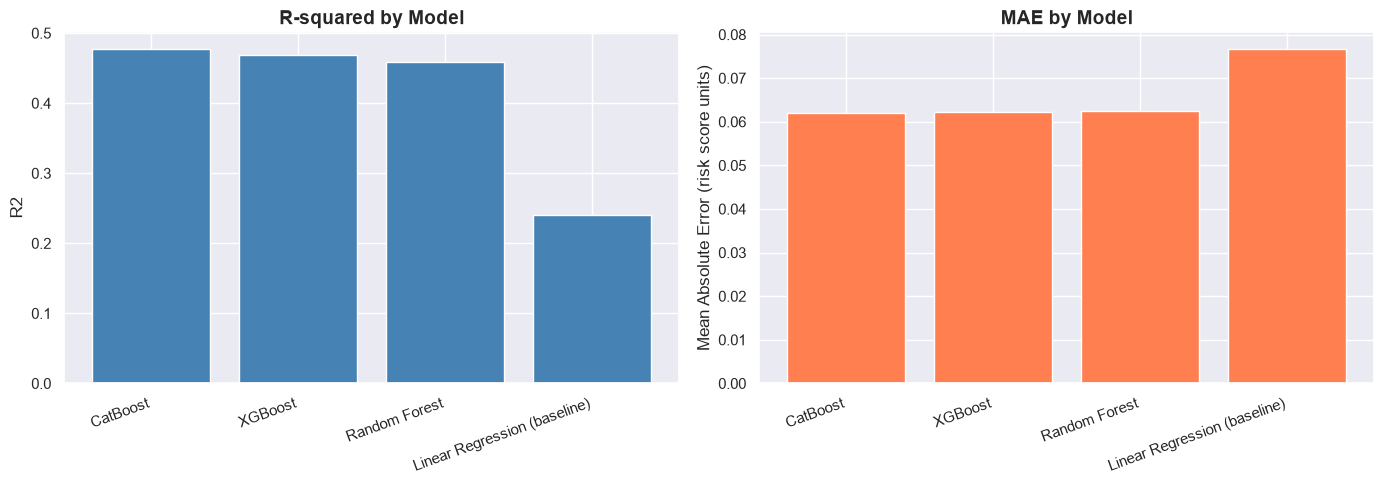


Interpretation:
  Priority metric is MAE -- each unit corresponds to a risk-score point.
  R2 reflects how much variance the SAFE features explain independently.
  A low R2 here is expected (same logic as provider notebook): every column
  that strongly predicts this score was excluded to prevent leakage.


In [42]:
results_df = pd.DataFrame(results).sort_values('R2', ascending=False).reset_index(drop=True)

print("="*70)
print("  MODEL COMPARISON -- Patient Risk Score Regression (Leak-Free)")
print("="*70)
display(results_df.round(4))

best_name = results_df.iloc[0]['Model']
print(f"\nBest model by R2: {best_name}")

pmap  = {"Linear Regression (baseline)": lr_preds, "Random Forest": rf_preds,
          "XGBoost": xgb_preds, "CatBoost": cat_preds}
plmap = {"Linear Regression (baseline)": lr_pipe, "Random Forest": rf_pipe,
          "XGBoost": xgb_pipe, "CatBoost": cat_pipe}

BEST_PIPE  = plmap[best_name]
BEST_PREDS = pmap[best_name]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].bar(results_df['Model'], results_df['R2'], color='steelblue', edgecolor='white')
axes[0].set_title("R-squared by Model")
axes[0].set_ylabel("R2")
axes[0].axhline(0, color='gray', linewidth=0.8)
plt.setp(axes[0].get_xticklabels(), rotation=20, ha='right')

axes[1].bar(results_df['Model'], results_df['MAE'], color='coral', edgecolor='white')
axes[1].set_title("MAE by Model")
axes[1].set_ylabel("Mean Absolute Error (risk score units)")
plt.setp(axes[1].get_xticklabels(), rotation=20, ha='right')

plt.tight_layout()
plt.savefig("..\\patient_risk_images\section10_model_comparison.png", dpi=100, bbox_inches='tight')
plt.show()

print()
print("Interpretation:")
print("  Priority metric is MAE -- each unit corresponds to a risk-score point.")
print("  R2 reflects how much variance the SAFE features explain independently.")
print("  A low R2 here is expected (same logic as provider notebook): every column")
print("  that strongly predicts this score was excluded to prevent leakage.")


---
## 11. Error Analysis — Hardest-to-Predict Patients <a id='11'></a>

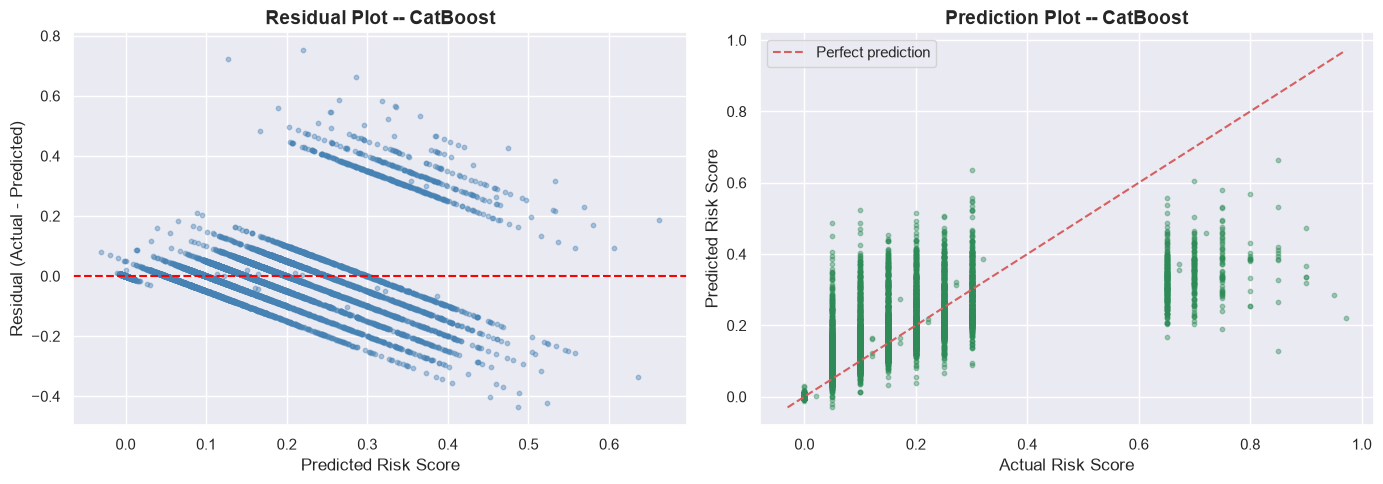

In [43]:
residuals_series = pd.Series(y_test.values - BEST_PREDS, index=y_test.index)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(BEST_PREDS, y_test.values - BEST_PREDS, alpha=0.4, s=10, color='steelblue')
axes[0].axhline(0, color='red', linestyle='--')
axes[0].set_title(f"Residual Plot -- {best_name}")
axes[0].set_xlabel("Predicted Risk Score")
axes[0].set_ylabel("Residual (Actual - Predicted)")

axes[1].scatter(y_test.values, BEST_PREDS, alpha=0.4, s=10, color='seagreen')
lims = [min(y_test.min(), BEST_PREDS.min()), max(y_test.max(), BEST_PREDS.max())]
axes[1].plot(lims, lims, 'r--', label='Perfect prediction')
axes[1].set_title(f"Prediction Plot -- {best_name}")
axes[1].set_xlabel("Actual Risk Score")
axes[1].set_ylabel("Predicted Risk Score")
axes[1].legend()

plt.tight_layout()
plt.savefig("..\\patient_risk_images\section11_residuals.png", dpi=100, bbox_inches='tight')
plt.show()


In [44]:
# Which patient profiles are hardest to predict?
# Build the error table from X_test (which has all feature columns) plus actuals and preds.
error_df = X_test.copy()
error_df[TARGET]           = y_test.values
error_df['predicted']      = BEST_PREDS
error_df['abs_error']      = np.abs(y_test.values - BEST_PREDS)
error_df['error_direction']= np.where(BEST_PREDS > y_test.values, 'Over-predicted', 'Under-predicted')

print("Top 20 highest-error patients:")
display(error_df.nlargest(20, 'abs_error')[
    ['age','gender','avg_days_between_claims',TARGET,'predicted','abs_error','error_direction']
].round(4))

print()
print("Over-prediction vs under-prediction split:")
print(error_df['error_direction'].value_counts().to_string())
print()
print("Error by gender (avg absolute error):")
print(error_df.groupby('gender')['abs_error'].mean().round(4).to_string())


Top 20 highest-error patients:


,age,gender,avg_days_between_claims,patient_risk_score,predicted,abs_error,error_direction
46473,87,Female,40.7857,0.9714,0.2198,0.7516,Under-predicted
108,32,Female,41.7273,0.8500,0.1277,0.7223,Under-predicted
37006,38,Other,51.6923,0.9500,0.2865,0.6635,Under-predicted
33869,56,Male,56.8182,0.8500,0.2652,0.5848,Under-predicted
47865,69,Female,48.2500,0.9000,0.3184,0.5816,Under-predicted
43678,46,Female,54.8333,0.9000,0.3346,0.5654,Under-predicted
27911,38,Male,56.9167,0.9000,0.3356,0.5644,Under-predicted
12007,22,Female,37.8889,0.7500,0.1889,0.5611,Under-predicted
23700,53,Female,43.9000,0.8000,0.2539,0.5461,Under-predicted
8952,89,Male,58.2000,0.8000,0.2554,0.5446,Under-predicted



Over-prediction vs under-prediction split:
error_direction
Over-predicted     5168
Under-predicted    4652

Error by gender (avg absolute error):
gender
Female    0.0630
Male      0.0605
Other     0.0684


---
## 12. SHAP Explainability <a id='12'></a>

Example narrative this section enables for a downstream LLM layer:

> Patient Risk = 0.35 (predicted)
> Main drivers:
>   + Visits many providers relative to average (avg_days_between_claims low)
>   + High month-end claim concentration
>   - Low avg settlement delay suggests normal processing


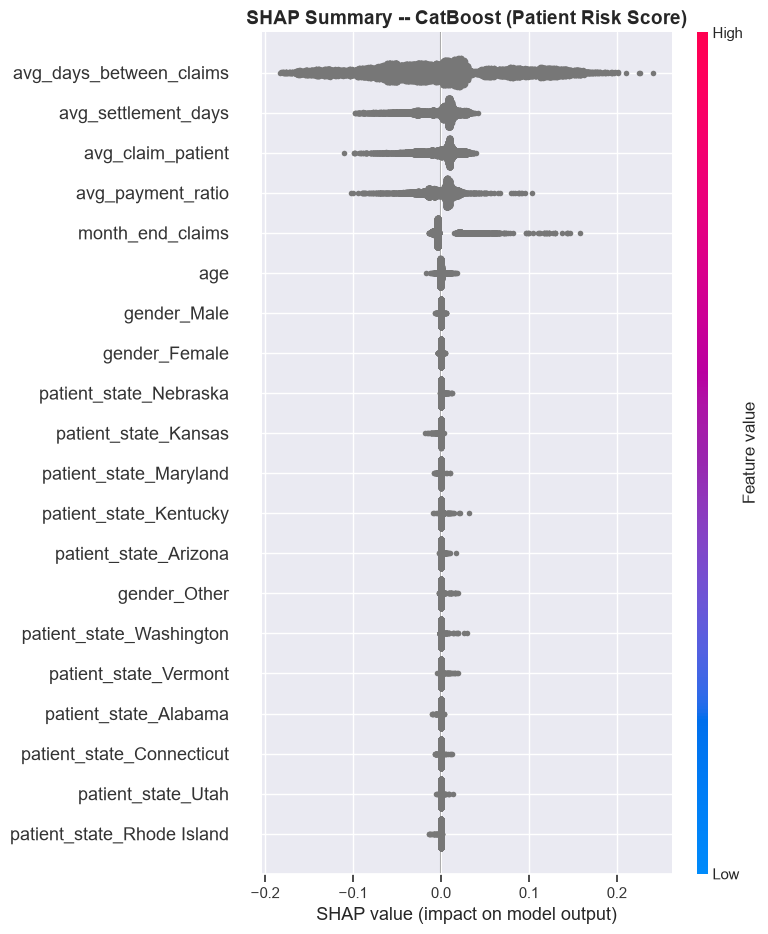

In [45]:
import shap

X_test_transformed = BEST_PIPE.named_steps['prep'].transform(X_test)

cat_feature_names = list(
    BEST_PIPE.named_steps['prep']
    .named_transformers_['cat']
    .named_steps['encoder']
    .get_feature_names_out(SAFE_CAT)
)
feature_names_all = SAFE_NUM + SAFE_PASS + cat_feature_names

model_step = BEST_PIPE.named_steps['model']

try:
    if best_name == "Linear Regression (baseline)":
        explainer = shap.LinearExplainer(model_step, X_test_transformed)
    else:
        explainer = shap.TreeExplainer(model_step)
    shap_values = explainer.shap_values(X_test_transformed)

    # Summary plot
    fig = plt.figure(figsize=(10, 6))
    shap.summary_plot(shap_values, X_test_transformed,
                       feature_names=feature_names_all, show=False)
    plt.title(f"SHAP Summary -- {best_name} (Patient Risk Score)")
    plt.tight_layout()
    plt.savefig("..\\patient_risk_images\section12_shap_summary.png", dpi=100, bbox_inches='tight')
    plt.show()
except Exception as e:
    print(f"SHAP not applicable to this model variant: {e}")


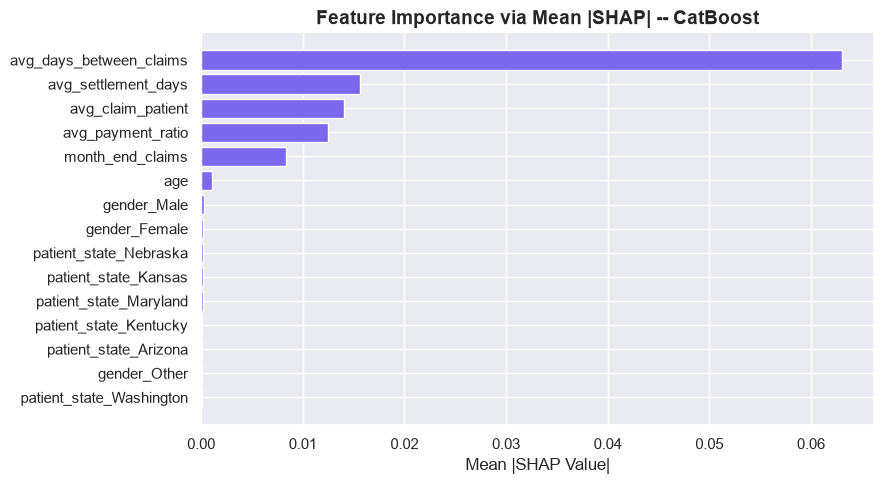

,Feature,Mean_SHAP
3,avg_days_between_claims,0.06305
2,avg_settlement_days,0.01561
0,avg_claim_patient,0.01409
1,avg_payment_ratio,0.01249
4,month_end_claims,0.00836
6,age,0.00107
8,gender_Male,0.00026
7,gender_Female,0.00020
36,patient_state_Nebraska,0.00014
25,patient_state_Kansas,0.00014


In [46]:
# Bar plot: mean absolute SHAP values
try:
    mean_shap = np.abs(shap_values).mean(axis=0)
    shap_imp = pd.DataFrame({'Feature': feature_names_all, 'Mean_SHAP': mean_shap})
    shap_imp = shap_imp.sort_values('Mean_SHAP', ascending=False).head(15)

    fig, ax = plt.subplots(figsize=(9, 5))
    ax.barh(shap_imp['Feature'], shap_imp['Mean_SHAP'], color='mediumslateblue', edgecolor='white')
    ax.set_title(f"Feature Importance via Mean |SHAP| -- {best_name}")
    ax.set_xlabel("Mean |SHAP Value|")
    ax.invert_yaxis()
    plt.tight_layout()
    plt.savefig("..\\patient_risk_images\section12_shap_importance.png", dpi=100, bbox_inches='tight')
    plt.show()
    display(shap_imp.round(5))
except Exception as e:
    print(f"SHAP importance bar chart not available: {e}")


In [47]:
# Waterfall: single highest-risk patient's explanation
try:
    high_risk_idx = y_test.values.argmax()
    exp_actual    = y_test.values[high_risk_idx]
    exp_predicted = BEST_PREDS[high_risk_idx]

    print(f"Highest-risk test patient: actual={exp_actual:.4f}  predicted={exp_predicted:.4f}")

    fig = plt.figure(figsize=(10, 4))
    base_val = explainer.expected_value
    if isinstance(base_val, np.ndarray): base_val = base_val[0]
    shap.waterfall_plot(shap.Explanation(
        values=shap_values[high_risk_idx],
        base_values=base_val,
        data=X_test_transformed[high_risk_idx],
        feature_names=feature_names_all,
    ), show=False)
    plt.title("SHAP Waterfall -- Highest-Risk Patient in Test Set")
    plt.tight_layout()
    plt.savefig("..\\patient_risk_images\section12_shap_waterfall.png", dpi=100, bbox_inches='tight')
    plt.show()
except Exception as e:
    print(f"Waterfall plot not available: {e}")


Highest-risk test patient: actual=0.9714  predicted=0.2198
Waterfall plot not available: index (2) out of range


---
## 13. Save Artifacts <a id='13'></a>

In [48]:
# Save trained pipeline and feature column list
with open("..\\models\patient_risk_model.pkl", 'wb') as f:
    pickle.dump(BEST_PIPE, f)

with open("..\\models\patient_feature_columns.pkl", 'wb') as f:
    pickle.dump(FEATURE_COLS, f)

# Save predictions back onto the patient table for downstream use
patient_df_out = patient_df.copy()
patient_df_out['predicted_risk_score'] = BEST_PIPE.predict(patient_df[FEATURE_COLS])
patient_df_out.to_csv("..\\risk_predict_data\patient_risk_predictions.csv", index=False)

print("Artifacts saved:")
print("  patient_risk_model.pkl          -- trained pipeline")
print("  patient_feature_columns.pkl     -- feature column list for inference")
print("  patient_risk_predictions.csv    -- all patients + predicted risk score")
print()
print("Usage for inference on a new patient record:")
print("""
  import pickle
  model = pickle.load(open('patient_risk_model.pkl', 'rb'))
  cols  = pickle.load(open('patient_feature_columns.pkl', 'rb'))
  score = model.predict(new_patient_df[cols])
""")


Artifacts saved:
  patient_risk_model.pkl          -- trained pipeline
  patient_feature_columns.pkl     -- feature column list for inference
  patient_risk_predictions.csv    -- all patients + predicted risk score

Usage for inference on a new patient record:

  import pickle
  model = pickle.load(open('patient_risk_model.pkl', 'rb'))
  cols  = pickle.load(open('patient_feature_columns.pkl', 'rb'))
  score = model.predict(new_patient_df[cols])



---
## 14. Summary <a id='14'></a>

In [49]:
print("="*70)
print("  06_PATIENT_RISK_MODELING -- SUMMARY")
print("="*70)

print()
print("FORMULA VERIFIED")
print("  patient_risk_score = 0.40*MinMax(unique_providers_visited)")
print("                     + 0.30*patient_shopping_flag")
print("                     + 0.30*MinMax(claims_per_patient)")

print()
print("LEAKAGE AUDIT")
print(f"  Direct formula terms banned (3): unique_providers_visited,")
print(f"    patient_shopping_flag, claims_per_patient")
print(f"  2nd-order proxy leaks banned (3): patient_lifetime_value,")
print(f"    active_months, unique_specialties")
print(f"  Leak-free features used ({len(FEATURE_COLS)}): {FEATURE_COLS}")

print()
print("MODEL COMPARISON")
print(results_df.round(4).to_string(index=False))

print()
print(f"BEST MODEL: {best_name}")
best_row = results_df.iloc[0]
print(f"  R2   = {best_row['R2']:.4f}")
print(f"  MAE  = {best_row['MAE']:.4f}")
print(f"  RMSE = {best_row['RMSE']:.4f}")
print(f"  MAPE = {best_row['MAPE_%']:.1f}%")

print()
print("ARTIFACTS SAVED")
print("  patient_risk_model.pkl")
print("  patient_feature_columns.pkl")
print("  patient_risk_predictions.csv")

print()
print("NEXT STEPS")
print("  1. 07_Anomaly_Detection.ipynb -- apply Isolation Forest at the patient")
print("     level using the high-MI behavioral features (unique_providers_visited,")
print("     claims_per_patient, unique_specialties). Leakage does not apply to")
print("     unsupervised outlier detection because there is no target to leak into.")
print("  2. Combine predicted_patient_risk (this notebook) with anomaly_score")
print("     (next notebook) for a patient investigation-priority queue.")
print("  3. Pass SHAP explanations to the LLM layer to generate plain-English")
print("     narratives: 'Patient X is flagged because...'")


  06_PATIENT_RISK_MODELING -- SUMMARY

FORMULA VERIFIED
  patient_risk_score = 0.40*MinMax(unique_providers_visited)
                     + 0.30*patient_shopping_flag
                     + 0.30*MinMax(claims_per_patient)

LEAKAGE AUDIT
  Direct formula terms banned (3): unique_providers_visited,
    patient_shopping_flag, claims_per_patient
  2nd-order proxy leaks banned (3): patient_lifetime_value,
    active_months, unique_specialties
  Leak-free features used (9): ['avg_claim_patient', 'avg_payment_ratio', 'avg_settlement_days', 'avg_days_between_claims', 'month_end_claims', 'duplicate_rate', 'age', 'gender', 'patient_state']

MODEL COMPARISON
                       Model    MAE   RMSE     R2  MAPE_%
                    CatBoost 0.0620 0.1042 0.4770 46.2842
                     XGBoost 0.0621 0.1051 0.4680 46.1419
               Random Forest 0.0624 0.1060 0.4589 47.2348
Linear Regression (baseline) 0.0766 0.1256 0.2409 64.8024

BEST MODEL: CatBoost
  R2   = 0.4770
  MAE  = 0.0620
